In [302]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from pathlib import Path
from typing import Union
import json
import glob
import yaml

In [303]:
def json_to_dict(json_file_path: Union[str, Path]):
    """
    The function `json_to_dict` reads a JSON file and returns its contents as a
    dictionary.

    Args:
      json_file_path (Union[str, Path]): The `json_file_path` parameter is the
      file path to the JSON
    file that you want to read and convert into a Python dictionary. This
    function reads the JSON data from the specified file and returns it as a
    dictionary.

    Returns:
      The function `json_to_dict` returns a dictionary object containing the
      data loaded from the JSON
    file located at the specified file path.
    """
    with open(json_file_path, "r", encoding="utf-8") as file:
        json_dict = json.load(file)

    file.close()

    return json_dict

In [304]:
def read_config(path_directory: Union[str, Path]):
    """
    The `read_config` function reads a YAML file containing experiment configuration data and
    returns the parsed configuration.

    Returns:
      The function `read_config` returns the experiment configuration data loaded from the
      first YAML file found in the specified directory.
    """
    # yaml_files = glob.glob(str(Path(path_directory, "*.yaml")))
    yaml_data = open(path_directory, "r", encoding="utf-8")
    yaml_config = yaml.safe_load(yaml_data)
    yaml_data.close()

    return yaml_config

### Import Batch Data and Yaml Config File

In [305]:
file_path = Path.cwd() / "data"
folder = "SAM-1000L-B7H4-experiment"
filename_data = "SAM-1000L-B7H4-MasterDataTable.json"
filename_yaml = "SAM-1000L-B7H4.yaml"
full_path_data = file_path / folder / filename_data
full_path_yaml = file_path / folder / filename_yaml

data = json_to_dict(full_path_data)
yaml = read_config(full_path_yaml)
yaml

{'Asset': 'B7H4',
 'Vessel ID': 'FER027',
 'Campaign ID': 'GSK5730912',
 'Lot ID': '57309120M00D00',
 'Batch ID': '5730912101002F',
 'Inoc Date': datetime.date(2025, 11, 21),
 'Last Day': 14,
 'Feed Type': 'B',
 'Tubing Factor': 7.2,
 'Maximum Pump Speed': 190,
 'Bolus Feed Flowrate': 1360,
 'Scale': '1000L',
 'Initial Volumes': {'ambr250': 0.19, '1000L': 740.0, '2000L': 1740.0},
 'Volume Unit': 'L',
 'Feed Unit': 'mL',
 'Master Data File': 'SAM-1000L-B7H4-MasterDataTable.json',
 'Units Dictionary': {'IGG': 'mg/L',
  'LDH': 'mg/L',
  'TCC': 'MM cells/mL',
  'VCC': 'MM cells/mL',
  'VIABILITY': '%',
  'DIAMETER': 'um',
  'OSMOLALITY': 'mOsm/kg',
  'AMMONIUM': 'mM',
  'CALCIUM': 'mg/L',
  'GLUCOSE': 'g/L',
  'GLUTAMINE': 'mM',
  'GLUTAMATE': 'mM',
  'LACTATE': 'g/L',
  'PH': '',
  'PCO2': 'mmHg',
  'PO2': 'mmHg',
  'POTASSIUM': 'mg/L',
  'SODIUM': 'mg/L',
  'BICARBONATE': None,
  'PCO2_AT_TEMP': 'mmHg',
  'PO2_AT_TEMP': 'mmHg',
  'PH_AT_TEMP': '',
  'PH_SETPOINT': '',
  'TEMPERATURE_SETP

In [306]:
folder = r"C:\Users\zah48132\GSK\Biopharm Model Predictive Control - Documents\General\doc\SAM Lab 1000L Batch November 2025"
file = "CTM_data_for_titer_trajectory.csv"
file_path = Path(folder, file)

df = pd.read_csv(file_path)
df_ctm = df.loc[df["Location"]=="B38", :]
grouped = df_ctm.groupby("Day")["titer"].agg(['mean','std'])
df_agg = grouped.reset_index()
df_agg

,Day,mean,std
0,0,21.050000,4.030509
1,1,33.150000,2.616295
2,2,59.550000,10.253048
3,3,120.328571,13.004578
4,4,230.314286,22.308999
5,5,408.971429,35.335332
6,6,708.442857,53.809474
7,7,1046.471429,64.357302
8,8,1491.571429,62.262233
9,9,1845.685714,64.588503


In [307]:
# Gather all Titer data
time_data = pd.to_datetime(pd.Series([values["time"] for _, values in data.items()]), unit='ms', utc=True).dt.tz_convert("America/New_York")
batch_data = np.array([values["titre"] for _, values in data.items()])
cedex_titer = np.array([
    v if v is not None else np.nan
    for v in (vals["cedex_titer"] for vals in data.values())
])
raman_titer = np.array([values["raman_titer"] for _, values in data.items()])
hplc_titer = np.array([
    v if v is not None else np.nan
    for v in (vals["hplc_titer"] for vals in data.values())
])
titer_setpoint_trajectory = np.array(yaml["Controller"]["Process Variables"]["IGG"]["Data"])[:len(batch_data)]
ctm_avg_trajectory = df_agg["mean"].values[:len(batch_data)]

# Calculate setpoint tracking error
setpoint_tracking_error = 100*(batch_data-titer_setpoint_trajectory)/titer_setpoint_trajectory
setpoint_tracking_error_raman = 100*(raman_titer-titer_setpoint_trajectory)/titer_setpoint_trajectory
setpoint_tracking_error_hplc = 100*(hplc_titer-titer_setpoint_trajectory)/titer_setpoint_trajectory
setpoint_tracking_error_cedex = 100*(cedex_titer-titer_setpoint_trajectory)/titer_setpoint_trajectory
setpoint_tracking_error_ctm = 100*(ctm_avg_trajectory-titer_setpoint_trajectory)/titer_setpoint_trajectory

# Apply correction factor to CEDEX data
correction_factor = 0.13
corrected_hplc = cedex_titer*(1-correction_factor)
setpoint_tracking_error_cedex_corrected = 100*(corrected_hplc-titer_setpoint_trajectory)/titer_setpoint_trajectory

In [308]:
titer_results = pd.DataFrame({
    "Time": time_data,
    "Cedex Titer": cedex_titer,
    "Raman Titer": raman_titer,
    "HPLC Titer": hplc_titer,
    "Titer Setpoint": titer_setpoint_trajectory,
    "CTM Avg.": ctm_avg_trajectory
})
titer_results

,Time,Cedex Titer,Raman Titer,HPLC Titer,Titer Setpoint,CTM Avg.
0,2025-11-21 10:26:46.409000-05:00,81.55,-134.604270,22.4,21.050000,21.050000
1,2025-11-22 11:24:33.632000-05:00,81.55,-27.770000,38.1,33.386786,33.150000
2,2025-11-23 08:14:12.847000-05:00,88.91,-19.591527,69.6,60.400714,59.550000
3,2025-11-24 08:55:09.795000-05:00,153.62,-13.044402,136.0,122.907041,120.328571
4,2025-11-25 08:31:34.685000-05:00,294.48,145.848924,267.4,236.894694,230.314286
5,2025-11-26 08:34:55.952000-05:00,515.95,371.479461,472.0,423.577551,408.971429
6,2025-11-27 09:21:32.920000-05:00,852.00,671.221313,797.6,738.804694,708.442857
7,2025-11-28 09:04:34.734000-05:00,1218.22,970.264848,1163.3,1098.795000,1046.471429
8,2025-11-29 08:39:21.272000-05:00,1724.34,1426.332619,1551.0,1576.804082,1491.571429
9,2025-11-30 08:54:44.671000-05:00,2212.43,1943.398314,1983.9,1964.336939,1845.685714


### Titer Trend

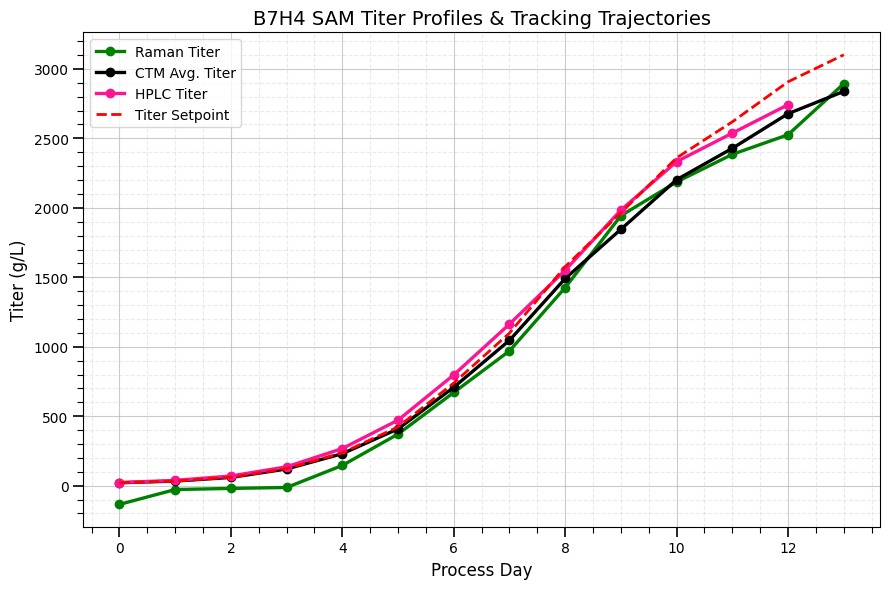

In [309]:
plt.figure(figsize=(9, 6))

x = np.arange(len(batch_data))

line_width = 2.4
marker_size = 6

# --- Main data series ---
plt.plot(x, raman_titer,
         color="green", linewidth=line_width,
         marker="o", markersize=marker_size,
         label="Raman Titer")

plt.plot(x, ctm_avg_trajectory,
         color="black", linewidth=line_width,
         marker="o", markersize=marker_size,
         label="CTM Avg. Titer")

# plt.plot(x, cedex_titer,
#          color="blueviolet", linewidth=line_width,
#          marker="o", markersize=marker_size,
#          label="Cedex Titer")

plt.plot(x, hplc_titer,
         color="deeppink", linewidth=line_width,
         marker="o", markersize=marker_size,
         label="HPLC Titer")

# --- Setpoint trajectory ---
plt.plot(x, titer_setpoint_trajectory,
         linestyle="--", color="red",
         linewidth=2, label="Titer Setpoint")

# --- Axes labels + title ---
plt.xlabel("Process Day", fontsize=12)
plt.ylabel("Titer (g/L)", fontsize=12)  # more correct than "Setpoint Tracking Error %"
plt.title("B7H4 SAM Titer Profiles & Tracking Trajectories", fontsize=14)

# --- Grid styling ---
plt.grid(which="major", linestyle="-", alpha=0.65)
plt.grid(which="minor", linestyle="--", alpha=0.25)
plt.minorticks_on()

# --- Tick appearance ---
plt.tick_params(axis="both", which="major", length=7, width=1.2)
plt.tick_params(axis="both", which="minor", length=4, width=0.8)

# --- Legend ---
plt.legend(frameon=True, fontsize=10, loc="best")

plt.tight_layout()


### Setpoint Tracking Graphs

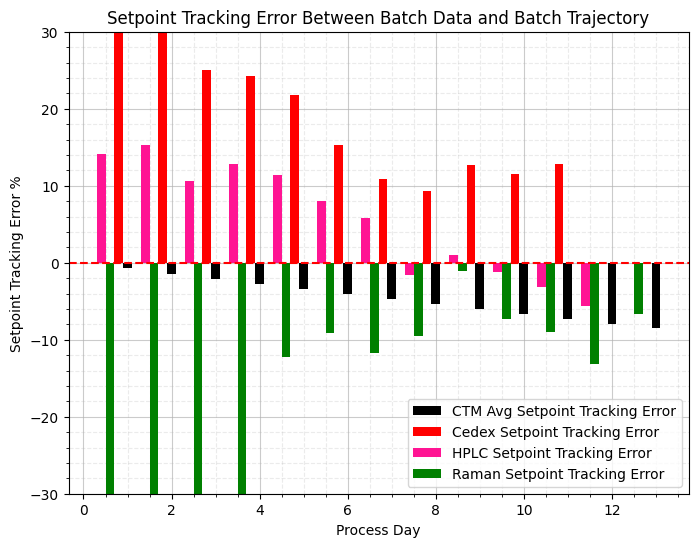

In [310]:
plt.figure(figsize=(8,6))
plt.bar(x=np.arange(0, len(batch_data))[1:], height=setpoint_tracking_error_ctm[1:], color="k", zorder=2, width=0.2, label="CTM Avg Setpoint Tracking Error")
plt.bar(x=np.arange(0, len(batch_data))[1:]-0.2, height=setpoint_tracking_error_cedex[1:], color="r", zorder=2, width=0.2, label="Cedex Setpoint Tracking Error")
plt.bar(x=np.arange(0, len(batch_data))[1:]-0.6, height=setpoint_tracking_error_hplc[1:], color="deeppink", zorder=2, width=0.2, label="HPLC Setpoint Tracking Error")
plt.bar(x=np.arange(0, len(batch_data))[1:]-0.4, height=setpoint_tracking_error_raman[1:], color="g", zorder=2, width=0.2, label="Raman Setpoint Tracking Error")

plt.axhline(0, linestyle="--", color="r")
plt.xlabel("Process Day")
plt.ylabel("Setpoint Tracking Error %")
plt.title("Setpoint Tracking Error Between Batch Data and Batch Trajectory")
plt.grid(zorder=1)
# Grid (major + subtle minor)
plt.grid(which="major", linestyle="-", alpha=0.65)
plt.grid(which="minor", linestyle="--", alpha=0.25)

# Add minor ticks
plt.minorticks_on()
plt.ylim(-30, 30)
plt.legend()

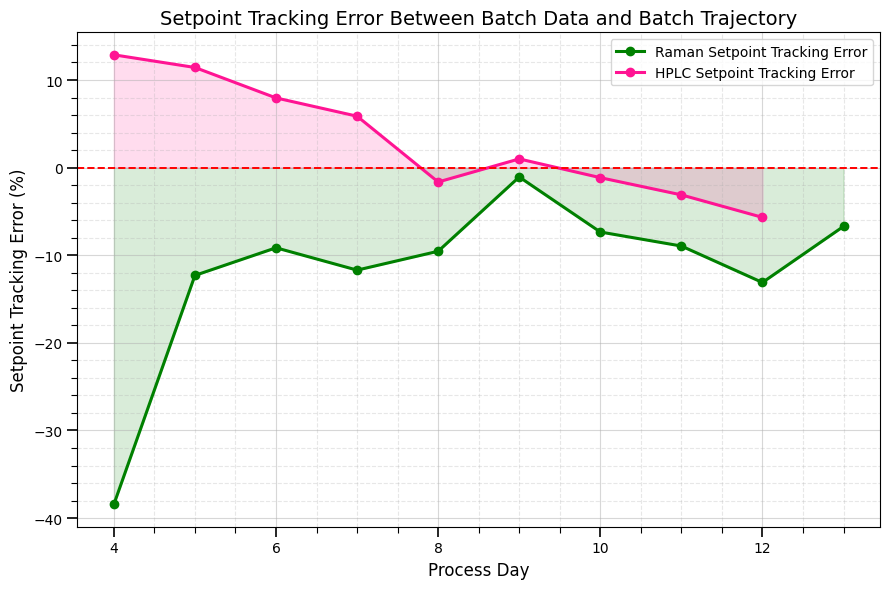

In [312]:
plt.figure(figsize=(9, 6))

start = 4

# Common x-axis
x = np.arange(start, len(batch_data))

# Plot styling parameters
line_width = 2.2
marker_size = 6
alpha_fill = 0.15

# plt.plot(x, setpoint_tracking_error_ctm[start:], 
#          color="black", linewidth=line_width, marker="o", markersize=marker_size,
#          label="CTM Avg Setpoint Tracking Error")
# plt.plot(x, setpoint_tracking_error_cedex[start:], 
#          color="blueviolet", linewidth=line_width, marker="o", markersize=marker_size,
#          label="Cedex Setpoint Tracking Error")
plt.plot(x, setpoint_tracking_error_raman[start:], 
         color="green", linewidth=line_width, marker="o", markersize=marker_size,
         label="Raman Setpoint Tracking Error")
plt.plot(x, setpoint_tracking_error_hplc[start:], 
         color="deeppink", linewidth=line_width, marker="o", markersize=marker_size,
         label="HPLC Setpoint Tracking Error")

# Fill area underneath each line
# plt.fill_between(x, setpoint_tracking_error_ctm[start:], alpha=alpha_fill, color="black")
# plt.fill_between(x, setpoint_tracking_error_cedex[start:], alpha=alpha_fill, color="blueviolet")
plt.fill_between(x, setpoint_tracking_error_raman[start:], alpha=alpha_fill, color="green")
plt.fill_between(x, setpoint_tracking_error_hplc[start:], alpha=alpha_fill, color="deeppink")

# Zero reference line
plt.axhline(0, linestyle="--", color="red", linewidth=1.4)

# Labels + title
plt.xlabel("Process Day", fontsize=12)
plt.ylabel("Setpoint Tracking Error (%)", fontsize=12)
plt.title("Setpoint Tracking Error Between Batch Data and Batch Trajectory", fontsize=14)

# Grid (major + subtle minor)
plt.grid(which="major", linestyle="-", alpha=0.50)
plt.grid(which="minor", linestyle="--", alpha=0.30)

# Add minor ticks
plt.minorticks_on()

# Ticks appearance
plt.tick_params(axis="both", which="major", length=7, width=1.2)
plt.tick_params(axis="both", which="minor", length=4, width=0.8)

# Limits
# plt.ylim(-40, 40)

# Legend formatting
plt.legend(frameon=True, fontsize=10, loc="upper right")

plt.tight_layout()
